## model avaluation

In [40]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [41]:
logistic_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [42]:
X_test_processed = pd.read_csv(
    "../data/processed/X_test_processed.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [43]:
y_test_pred = logistic_model.predict(
    X_test_processed
)

y_test_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [44]:
accuracy = accuracy_score(y_test, y_test_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8026969481902059


In [45]:
precision = precision_score(y_test, y_test_pred)

print("Precision:", precision)

Precision: 0.6632653061224489


In [47]:
recall = recall_score(y_test, y_test_pred)

print("Recall:", recall)

Recall: 0.5213903743315508


In [48]:
f1 = f1_score(y_test, y_test_pred)

print("F1 Score:", f1)

F1 Score: 0.5838323353293413


In [49]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[936  99]
 [179 195]]


In [50]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [51]:
roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8441189387480947


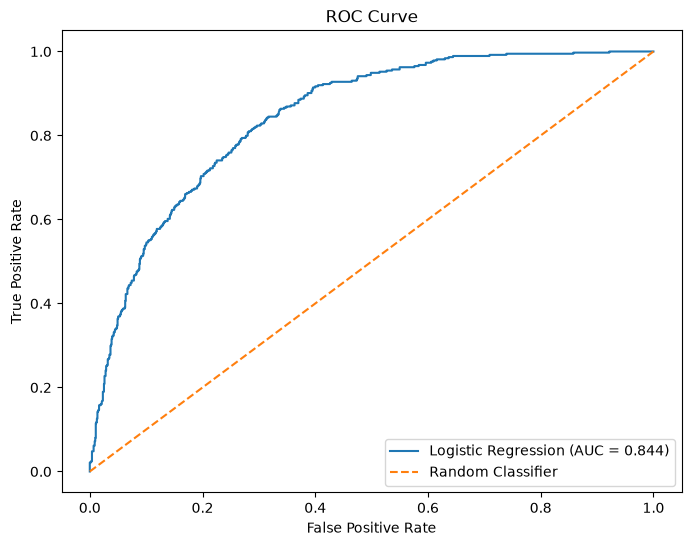

In [52]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [59]:
import joblib
import pandas as pd

balanced_logistic_model = joblib.load(
    "../models/balanced_logistic_regression_model.pkl"
)

print("Balanced Logistic Regression loaded successfully!")

Balanced Logistic Regression loaded successfully!


In [60]:
X_test_processed = pd.read_csv(
    "../data/processed/X_test_processed.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

print("Test data loaded successfully!")
print("X_test:", X_test_processed.shape)
print("y_test:", y_test.shape)

Test data loaded successfully!
X_test: (1409, 48)
y_test: (1409,)


In [61]:
y_test_pred_balanced = balanced_logistic_model.predict(
    X_test_processed
)

y_test_proba_balanced = balanced_logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Balanced model predictions generated successfully!")

Balanced model predictions generated successfully!


In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

balanced_accuracy = accuracy_score(
    y_test,
    y_test_pred_balanced
)

balanced_precision = precision_score(
    y_test,
    y_test_pred_balanced
)

balanced_recall = recall_score(
    y_test,
    y_test_pred_balanced
)

balanced_f1 = f1_score(
    y_test,
    y_test_pred_balanced
)

balanced_roc_auc = roc_auc_score(
    y_test,
    y_test_proba_balanced
)

print("Balanced Logistic Regression")
print("--------------------------------")
print("Accuracy :", balanced_accuracy)
print("Precision:", balanced_precision)
print("Recall   :", balanced_recall)
print("F1 Score :", balanced_f1)
print("ROC-AUC  :", balanced_roc_auc)

Balanced Logistic Regression
--------------------------------
Accuracy : 0.7395315826827538
Precision: 0.505922165820643
Recall   : 0.7994652406417112
F1 Score : 0.6196891191709845
ROC-AUC  : 0.8436332635821127


Confusion Matrix:
[[743 292]
 [ 75 299]]


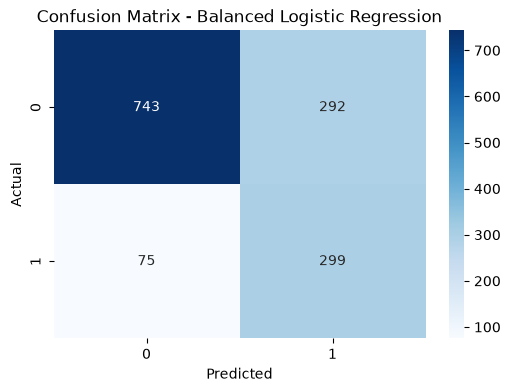

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_balanced = confusion_matrix(
    y_test,
    y_test_pred_balanced
)

print("Confusion Matrix:")
print(cm_balanced)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred_balanced,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



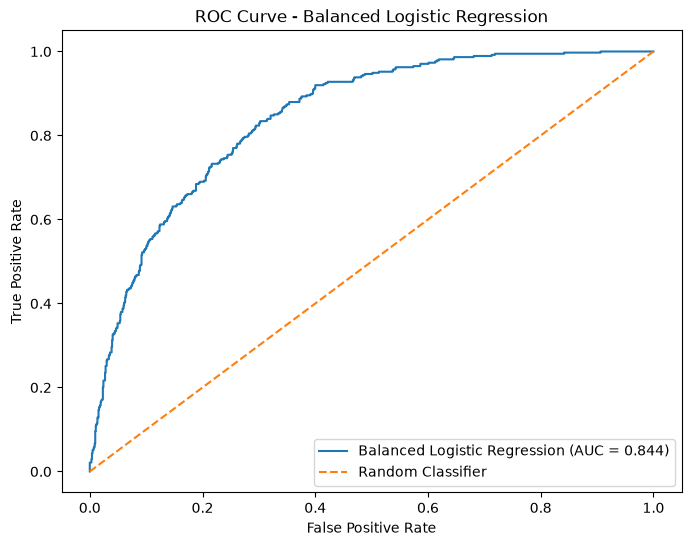

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_balanced, tpr_balanced, thresholds = roc_curve(
    y_test,
    y_test_proba_balanced
)

auc_balanced = roc_auc_score(
    y_test,
    y_test_proba_balanced
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_balanced,
    tpr_balanced,
    label=f"Balanced Logistic Regression (AUC = {auc_balanced:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Logistic Regression")
plt.legend()
plt.show()

In [66]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        0.8027,
        balanced_accuracy
    ],
    "Precision": [
        0.6633,
        balanced_precision
    ],
    "Recall": [
        0.5214,
        balanced_recall
    ],
    "F1 Score": [
        0.5838,
        balanced_f1
    ],
    "ROC-AUC": [
        0.8441,
        balanced_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802700,0.663300,0.521400,0.583800,0.844100
1,Balanced Logistic Regression,0.739532,0.505922,0.799465,0.619689,0.843633


In [67]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy
    ],
    "Precision": [
        precision,
        balanced_precision
    ],
    "Recall": [
        recall,
        balanced_recall
    ],
    "F1 Score": [
        f1,
        balanced_f1
    ],
    "ROC-AUC": [
        roc_auc,
        balanced_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802697,0.663265,0.521390,0.583832,0.844119
1,Balanced Logistic Regression,0.739532,0.505922,0.799465,0.619689,0.843633


In [68]:
best_model = balanced_logistic_model

print("Selected Model: Balanced Logistic Regression")

Selected Model: Balanced Logistic Regression


In [69]:
joblib.dump(
    best_model,
    "../models/final_churn_model.pkl"
)

print("Final churn model saved successfully!")

Final churn model saved successfully!
